# Import Essential Library

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
import matplotlib.pyplot as plt
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [2]:
import zipfile

zip_path = r"C:\Users\AMIT KUMAR\Downloads\archive (4).zip"
extract_path = r"C:\Users\AMIT KUMAR\OneDrive\Documents\extracted_files"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

Extracted successfully!


In [3]:
# Loads and batches training images with labels inferred from folder names.
train_ds = keras.utils.image_dataset_from_directory(
    directory = r'C:\Users\AMIT KUMAR\OneDrive\Documents\extracted_files',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(300,300))

# Loads and batches validation images from the same directory structure.
validation_ds = keras.utils.image_dataset_from_directory(
    directory = r'C:\Users\AMIT KUMAR\OneDrive\Documents\extracted_files',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(300,300))

Found 1655 files belonging to 6 classes.
Found 1655 files belonging to 6 classes.


In [4]:
# Normalize the image
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [5]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(300,300,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(6,activation='softmax'))

C:\Users\AMIT KUMAR\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 300, 300, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 150, 150, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 150, 150, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 38, 38, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 184832)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,658,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,760,518 (90.64 MB)

 Trainable params: 23,760,518 (90.64 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(train_ds,epochs=3,validation_data=validation_ds)

Epoch 1/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 1.0000 - loss: 3.8707e-05 - val_accuracy: 1.0000 - val_loss: 4.2580e-05
Epoch 2/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 1.0000 - loss: 4.0202e-05 - val_accuracy: 1.0000 - val_loss: 4.0102e-05
Epoch 3/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 1.0000 - loss: 3.4037e-05 - val_accuracy: 1.0000 - val_loss: 3.7953e-05


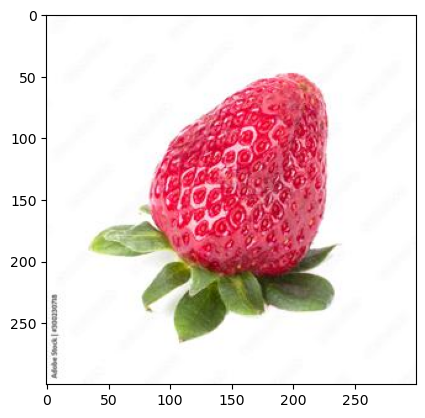

In [49]:
# plt.imshow(test_img)

import matplotlib.pyplot as plt
import cv2

img = cv2.imread(r'C:\Users\AMIT KUMAR\AppData\Local\Temp\cdf61fce-835c-40f1-b6a4-7586a20b123e_archive (4).zip.23e\fresh_strawberries_done\fresh_strawberry_9.jpg',cv2.IMREAD_COLOR)  # BGR format
test_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

plt.imshow(test_img)
plt.show()

In [50]:
print(test_img.shape)

(300, 300, 3)


In [51]:
test_input = test_img.reshape((1,300,300,3))

In [52]:
# Predict the model
model.predict(test_input).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


2